### Plot training and validations losses

In [1]:
import numpy as np
N=40
i=9
opt_data='minlp_ol'

network_info = np.load('training_data//' + opt_data + '_N%d_%.3d_' %(N,i) + 'info.npy', allow_pickle=True).item()

loss_train = network_info['loss_train']
loss_val = network_info['loss_val']

print(network_info['number_iterations'], network_info['lr'],network_info['hidden_size'], network_info['network_type'], network_info['dropout'], network_info['training_time'])

# network_info.keys()

213287 0.0001 1024 Network 0.0 83700.22239232063


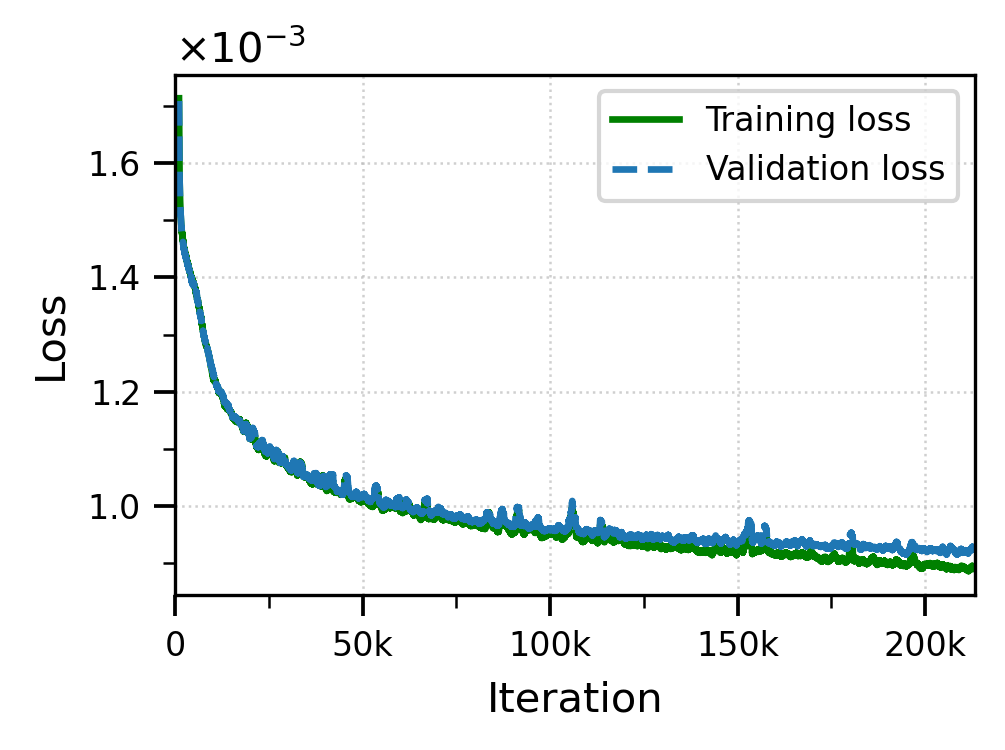

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter, AutoMinorLocator

def moving_average(x, window: int):
    x = np.asarray(x, dtype=float)
    if window <= 1:
        return x
    if window > len(x):
        raise ValueError("window must be <= len(x)")
    return np.convolve(x, np.ones(window) / window, mode="valid")

# ---- your data (lists) ----
train_loss = network_info['loss_train']
val_loss   = network_info['loss_val']

iters = np.arange(len(train_loss))

# ---- smoothing ----
window = 1000  # typical: 10–30
train_s = moving_average(train_loss, window)
val_s   = moving_average(val_loss, window)
iters_s = iters[window - 1:]

# ---- single-column size for double-column journals ----
fig, ax = plt.subplots(figsize=(3.45, 2.6), dpi=300)

# ---- Force y-axis to start at zero ----
ax.set_ylim(bottom=0)

# ---- X-axis formatter: 50k, 100k, etc. ----
def format_k(x, pos):
    if x >= 1000:
        return f"{x/1000:.0f}k"
    else:
        return f"{int(x)}"

ax.xaxis.set_major_formatter(FuncFormatter(format_k))

# ---- Y-axis formatter: scientific notation (1.2×10^{-3}) ----
y_formatter = ScalarFormatter(useMathText=True)
y_formatter.set_powerlimits((-2, 2))   # forces sci notation around 1e-3
ax.yaxis.set_major_formatter(y_formatter)

# # Optional: slightly fewer ticks for cleaner look
# ax.locator_params(axis='x', nbins=5)
# ax.locator_params(axis='y', nbins=5)

# ---- Minor ticks (subtle) ----
ax.xaxis.set_minor_locator(AutoMinorLocator(2))   # 1 minor between majors
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(axis="both", which="major", length=5, width=0.9)
ax.tick_params(axis="both", which="minor", length=3, width=0.6)

# ---- Light Elsevier-style grid (major only) ----
ax.grid(
    True,
    which="major",
    linestyle=":",
    linewidth=0.5,
    alpha=0.6
)


# optional raw curves (faint, excluded from legend)
# ax.plot(iters, train_loss, linewidth=0.8, alpha=0.25, label="_nolegend_")
# ax.plot(iters, val_loss,   linewidth=0.8, alpha=0.25, label="_nolegend_")

# smoothed curves (shown in legend)
ax.plot(iters_s, train_s, linewidth=1.6, color='green' , label="Training loss")
ax.plot(iters_s, val_s,   linewidth=1.6, color='red', linestyle="--", label="Validation loss")

ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_xlim(0, len(train_loss) - 1)

# y-limits with small padding for cleaner look
ymin = min(train_s.min(), val_s.min())
ymax = max(train_s.max(), val_s.max())
pad = 0.05 * (ymax - ymin + 1e-12)
ax.set_ylim(ymin - pad, ymax + pad)

ax.grid(True, linestyle=":", linewidth=0.6)
ax.tick_params(axis="both", labelsize=8)

ax.legend(loc="best", frameon=True, fontsize=8)
fig.tight_layout()

fig.savefig("loss_convergence.pdf", bbox_inches="tight")  # vector output
plt.show()


### End of plotting

In [ ]:
# import numpy as np
# N=40
# opt = 'milp_cl'
# n_workers = 20
# milp_info_compressed = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt,N, 0), allow_pickle=True).item()['milp_info_compressed']
# for job_idx in range(1,n_workers):
#     tmp_vector = np.load('data_optimal//data_%s_N%.2d_%.3d.npy' %(opt, N, job_idx), allow_pickle=True).item()['milp_info_compressed']
#     milp_info_compressed = np.concatenate((milp_info_compressed, tmp_vector))
# milp_info_compressed = milp_info_compressed[:120000, :]
# np.save('data_optimal//data_%s_N%.2d_condensed.npy' %(opt,N), milp_info_compressed, allow_pickle=True)

In [5]:
import numpy as np
N = 40
opt = 'milp_cl'
milp_info_compressed = np.load('data_optimal//data_%s_N%.2d_condensed.npy' %(opt,N), allow_pickle=True)
milp_info_compressed.shape

(120000, 5593)

In [10]:
from rail_data_preprocess_original import get_preprocessed_data

threshold_counts = 25

output_get_preprocessed_data = get_preprocessed_data(opt, threshold_counts, N)

# N = output_get_preprocessed_data[0]
N_control = output_get_preprocessed_data[1]
# stacked_states_train=output_get_preprocessed_data[2]
# stacked_states_val=output_get_preprocessed_data[3]
stacked_actions_reduced_train=output_get_preprocessed_data[4]
stacked_actions_reduced_val=output_get_preprocessed_data[5]
list_masks=output_get_preprocessed_data[6]
stacked_states_train_tensor=output_get_preprocessed_data[7]
stacked_states_val_tensor=output_get_preprocessed_data[8]
# state_min_reduced=output_get_preprocessed_data[9]
# state_max_reduced=output_get_preprocessed_data[10]
input_size=output_get_preprocessed_data[11]
total_action_set=output_get_preprocessed_data[12]

num_actions = total_action_set.shape[0]
seq_len=N_control

num_actions = 256
number of training points (before reduction): 96000
number of validation points (before reduction): 24000
number of training points (after reduction): 89112
number of validation points (after reduction): 22337
cntr_outlier_train: 6888	 cntr_outlier_val: 1663
data-processing finished
